# **Aula 2: Análise Exploratória com Matplotlib e Seaborn**



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import os 

## 🚚 **PBL: Diagnóstico de Eficiência da Smart Logística S.A.**

**Explorando dados como um analista Dataset: [Smart Logistics Supply Chain Dataset](https://www.kaggle.com/datasets/ziya07/smart-logistics-supply-chain-dataset)**.

### **1. Cenário do Problema (O Contexto de Negócio)**

Você foi recentemente contratado(a) como Analista de Dados júnior pela Smart Logística S.A., uma empresa de logística que está enfrentando uma crise de eficiência.

Nas últimas reuniões de resultado, o diretor geral relatou dois problemas graves:

- **Aumento de Custos:** Os custos operacionais com combustível e horas extras de motoristas dispararam, principalmente devido a tempos de espera não planejados e rotas ineficientes.

- **Queda na Satisfação do Cliente (CSAT):** As reclamações sobre atrasos (Logistics_Delay) aumentaram 35% no último trimestre.

O diretor suspeita que os problemas estejam interligados, mas não sabe onde atacar. A diretoria acredita que o problema é o tráfego (Traffic_Status), mas a equipe de operações culpa a falta de inventário (Inventory_Level) e os tempos de espera (Waiting_Time) nos pátios.

**Sua Missão:** A diretoria não quer um relatório técnico. Eles precisam de respostas. Seu trabalho é analisar o dataset Smart Logistics Supply Chain e preparar uma apresentação que responda às perguntas de negócio da liderança, identificando os verdadeiros gargalos da operação.

____
### **2. Entendimento inicial dos dados**

O nosso **primeiro passo** é ter uma visão geral da base de dados e para isso, vamos responder algumas questões:
- Quantas linhas nós temos?
- Quantas colunas nós temos? O que cada uma traz de informação?
- Quantas da variáveis são numéricas e categóricas?
- Existem dados faltantes nas colunas? Se sim, o que vamos fazer?
- Existem *outliers* nas colunas? Se sim, o que vamos fazer?
- O que vamos fazer com as variáveis categóricas?

In [7]:
current_path = os.getcwd()
current_path = current_path + "\\Dados"
current_path

'c:\\Users\\henrique.cordeiro\\OneDrive - Sociedade Campineira de Educação e Instrução\\A-POS\\LINGUAGEM DE PROGRAMAÇÃO PYTHON APLICADA A VISUALIZAÇÃO DE DADOS\\Dados'

In [9]:
df_logistica = pd.read_csv(os.path.join(current_path,"smart_logistics_dataset.csv"))
df_logistica

,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,NaN,60.1,285,1
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,355,3,NaN,99.2,260,0
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,227,5,Traffic,97.4,160,1
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,197,6,NaN,71.6,270,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2024-07-22 16:30:00,Truck_6,89.8701,73.6867,264,Delivered,26.9,70.0,Heavy,32,188,1,Weather,79.2,213,1
996,2024-04-30 04:58:58,Truck_5,-10.4792,-177.1239,479,Delivered,23.7,77.9,Detour,56,276,7,Weather,83.7,272,0
997,2024-10-27 22:09:13,Truck_2,-71.0609,75.3714,347,In Transit,21.0,63.1,Detour,35,382,5,NaN,74.8,275,0
998,2024-04-18 23:06:56,Truck_2,-76.7910,18.3631,276,Delivered,18.0,64.3,Heavy,10,361,5,NaN,88.6,242,1


In [10]:
df_logistica.head()

,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,NaN,60.1,285,1
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,355,3,NaN,99.2,260,0
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,227,5,Traffic,97.4,160,1
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,197,6,NaN,71.6,270,1


**Quantas linhas nós temos?**

In [11]:
len(df_logistica.index)

1000

**Quantas colunas nós temos? O que cada uma traz de informação?**


In [12]:
len(df_logistica.columns)

16

In [13]:
df_logistica.columns

Index(['Timestamp', 'Asset_ID', 'Latitude', 'Longitude', 'Inventory_Level',
       'Shipment_Status', 'Temperature', 'Humidity', 'Traffic_Status',
       'Waiting_Time', 'User_Transaction_Amount', 'User_Purchase_Frequency',
       'Logistics_Delay_Reason', 'Asset_Utilization', 'Demand_Forecast',
       'Logistics_Delay'],
      dtype='object')

- Timestamp: Data e hora em que os dados foram registrados, representando a atividade logística.
- Asset_ID: Identificador único para os ativos logísticos (ex: caminhões).
- Latitude & Longitude: Coordenadas geográficas do ativo para rastreamento e monitoramento.
- Inventory_Level: Nível atual de estoque associado ao ativo ou à remessa.
- Shipment_Status: Status da remessa (ex: Em Trânsito, Entregue, Atrasado).
- Temperature: Temperatura registrada no momento da remessa ou transporte.
- Humidity: Nível de umidade no momento do registro.
- Traffic_Status: Condição atual do tráfego (ex: Livre, Intenso, Desvio).
- Waiting_Time: Tempo gasto esperando durante o processo logístico (em minutos).
- User_Transaction_Amount: Valor monetário associado às transações do usuário.
- User_Purchase_Frequency: Frequência de compras feitas pelo usuário.
- Logistics_Delay_Reason: Motivo de quaisquer atrasos no processo logístico (ex: Clima, Falha Mecânica).
- Asset_Utilization: Percentual de utilização do ativo, indicando a eficácia com que os ativos estão sendo usados.
- Demand_Forecast: Demanda prevista para os serviços logísticos no próximo período.
- Logistics_Delay (Target): Variável binária indicando se ocorreu um atraso logístico (1 para atraso, 0 para sem atraso).

**Quantas da variáveis são numéricas e categóricas?**

In [14]:
df_logistica.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Timestamp                1000 non-null   object 
 1   Asset_ID                 1000 non-null   object 
 2   Latitude                 1000 non-null   float64
 3   Longitude                1000 non-null   float64
 4   Inventory_Level          1000 non-null   int64  
 5   Shipment_Status          1000 non-null   object 
 6   Temperature              1000 non-null   float64
 7   Humidity                 1000 non-null   float64
 8   Traffic_Status           1000 non-null   object 
 9   Waiting_Time             1000 non-null   int64  
 10  User_Transaction_Amount  1000 non-null   int64  
 11  User_Purchase_Frequency  1000 non-null   int64  
 12  Logistics_Delay_Reason   737 non-null    object 
 13  Asset_Utilization        1000 non-null   float64
 14  Demand_Forecast          

In [15]:
df_logistica.dtypes.value_counts()

int64      6
object     5
float64    5
Name: count, dtype: int64

**Existem dados faltantes nas colunas? Se sim, o que vamos fazer?**

In [16]:
df_logistica.isnull().sum()

Timestamp                    0
Asset_ID                     0
Latitude                     0
Longitude                    0
Inventory_Level              0
Shipment_Status              0
Temperature                  0
Humidity                     0
Traffic_Status               0
Waiting_Time                 0
User_Transaction_Amount      0
User_Purchase_Frequency      0
Logistics_Delay_Reason     263
Asset_Utilization            0
Demand_Forecast              0
Logistics_Delay              0
dtype: int64

O que podemos fazer?
- Criar uma observação "without delay" para os valores 0;
- Substituir os delays com base em alguma correlação entre as variáveis

**Existem *outliers* nas colunas? Se sim, o que vamos fazer?**

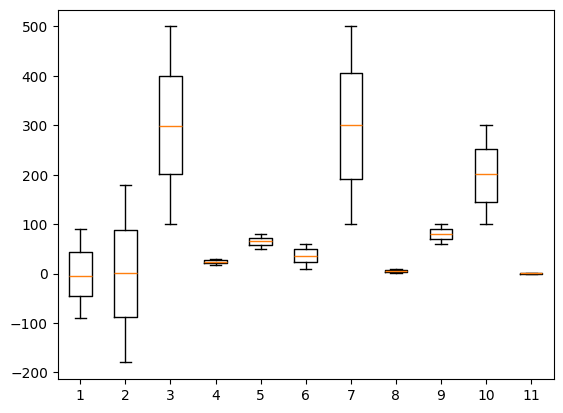

In [17]:
plt.boxplot(df_logistica.select_dtypes('number'))
plt.show()

In [18]:
df_logistica.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Timestamp                1000 non-null   object 
 1   Asset_ID                 1000 non-null   object 
 2   Latitude                 1000 non-null   float64
 3   Longitude                1000 non-null   float64
 4   Inventory_Level          1000 non-null   int64  
 5   Shipment_Status          1000 non-null   object 
 6   Temperature              1000 non-null   float64
 7   Humidity                 1000 non-null   float64
 8   Traffic_Status           1000 non-null   object 
 9   Waiting_Time             1000 non-null   int64  
 10  User_Transaction_Amount  1000 non-null   int64  
 11  User_Purchase_Frequency  1000 non-null   int64  
 12  Logistics_Delay_Reason   737 non-null    object 
 13  Asset_Utilization        1000 non-null   float64
 14  Demand_Forecast          

In [19]:
df_logistica.describe()

,Latitude,Longitude,Inventory_Level,Temperature,Humidity,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Asset_Utilization,Demand_Forecast,Logistics_Delay
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-1.360093,0.837049,297.915000,23.893900,65.042200,35.062000,299.055000,5.513000,79.599100,199.284000,0.566000
std,51.997183,104.843618,113.554773,3.322178,8.753765,14.477768,117.787792,2.935379,11.631153,59.920847,0.495873
min,-89.791500,-179.820200,100.000000,18.000000,50.000000,10.000000,100.000000,1.000000,60.000000,100.000000,0.000000
25%,-46.167975,-88.448075,201.000000,21.200000,57.200000,23.000000,191.750000,3.000000,69.475000,144.000000,0.000000
50%,-4.503150,0.678300,299.000000,23.800000,65.200000,35.000000,301.500000,6.000000,79.250000,202.000000,1.000000
75%,44.502800,88.156450,399.000000,26.600000,72.400000,49.000000,405.000000,8.000000,89.425000,251.250000,1.000000
max,89.870100,179.923700,500.000000,30.000000,80.000000,60.000000,500.000000,10.000000,100.000000,300.000000,1.000000


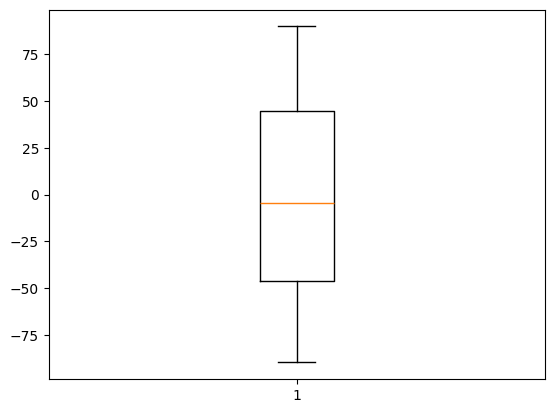

In [21]:
plt.boxplot(df_logistica['Latitude'])
plt.show()

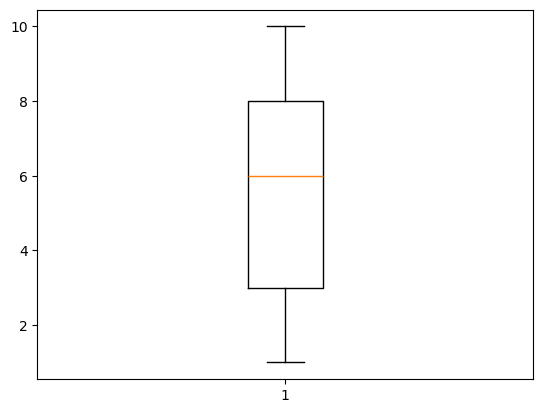

In [22]:
plt.boxplot(df_logistica['User_Purchase_Frequency'])
plt.show()

**O que vamos fazer com as variáveis categóricas?**

In [23]:
df_logistica.select_dtypes('object')

,Timestamp,Asset_ID,Shipment_Status,Traffic_Status,Logistics_Delay_Reason
0,2024-03-20 00:11:14,Truck_7,Delayed,Detour,NaN
1,2024-10-30 07:53:51,Truck_6,In Transit,Heavy,Weather
2,2024-07-29 18:42:48,Truck_10,In Transit,Detour,NaN
3,2024-10-28 00:50:54,Truck_9,Delivered,Heavy,Traffic
4,2024-09-27 15:52:58,Truck_7,Delayed,Clear,NaN
...,...,...,...,...,...
995,2024-07-22 16:30:00,Truck_6,Delivered,Heavy,Weather
996,2024-04-30 04:58:58,Truck_5,Delivered,Detour,Weather
997,2024-10-27 22:09:13,Truck_2,In Transit,Detour,NaN
998,2024-04-18 23:06:56,Truck_2,Delivered,Heavy,NaN


- Ordinal Encoder
- OneHot Encoder

____
### **3. Perguntas de Negócio (O Guia da Análise)**

#### **O Panorama Geral**

**Pergunta 1: Qual é a nossa taxa de atraso logístico (Logistics_Delay) geral?**

In [24]:
df_logistica['Logistics_Delay'].value_counts().reset_index()

,Logistics_Delay,count
0,1,566
1,0,434


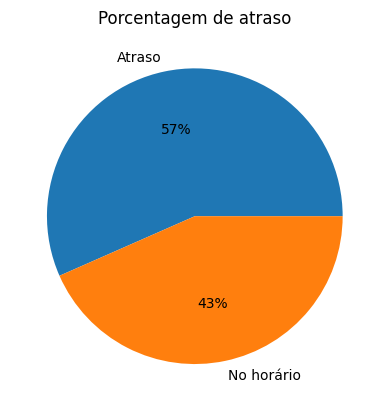

In [26]:
plt.pie(df_logistica['Logistics_Delay'].value_counts().reset_index()['count'],
        labels = ['Atraso','No horário'],
        autopct='%.0f%%')
plt.title('Porcentagem de atraso')
plt.show()

#### **Diagnóstico da Causa Raiz (Fatores Operacionais)**

**Pergunta 2: Qual é a relação direta entre o Waiting_Time (Tempo de Espera) e a ocorrência de um Logistics_Delay?**

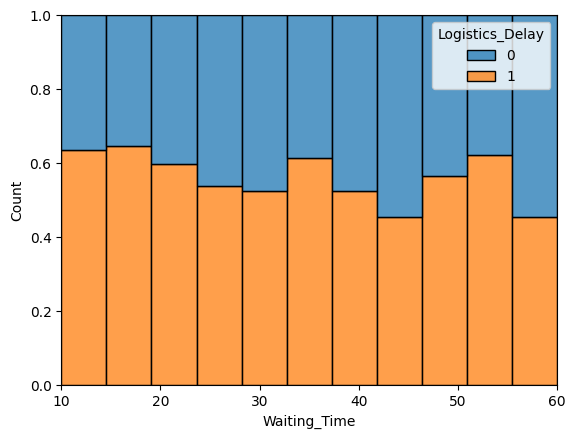

In [ ]:
sns.histplot(data = df_logistica, x  = 'Waiting_Time', hue = 'Logistics_Delay', multiple='fill')
plt.show()

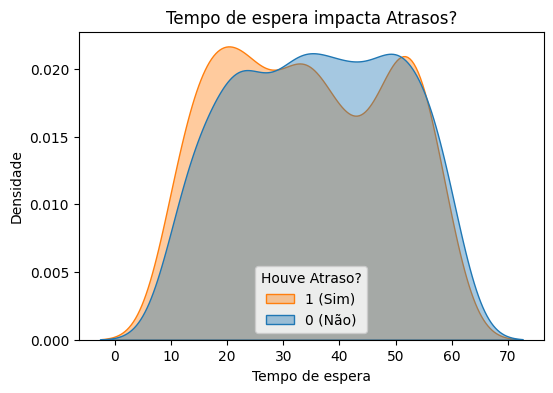

In [ ]:
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df_logistica,
            x='Waiting_Time',
            hue='Logistics_Delay', # Divide por Atraso (0 ou 1)
            fill=True,
            common_norm=False, # Mostra a forma de cada curva independentemente
            alpha=0.4) # Define a transparência

plt.title('Tempo de espera impacta Atrasos?')
plt.xlabel('Tempo de espera')
plt.ylabel('Densidade')
plt.legend(title='Houve Atraso?', labels=['1 (Sim)', '0 (Não)'])
plt.show()

**Pergunta 3: O Traffic_Status (Livre, Pesado, Desvio) é um fator determinante para os atrasos?**

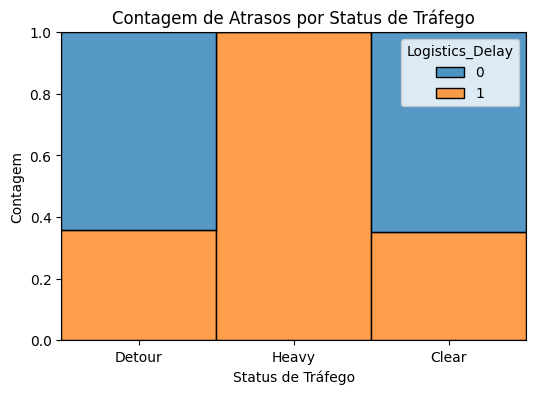

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data = df_logistica, x  = 'Traffic_Status', hue = 'Logistics_Delay', multiple='fill')
plt.title('Contagem de Atrasos por Status de Tráfego')
plt.xlabel('Status de Tráfego')
plt.ylabel('Contagem')
plt.show()

#### **Análise de Condições e Demanda (Fatores Externos)**

**Pergunta 4: Qual é a relação entre o Inventory_Level e a nossa Demand_Forecast? Estamos com excesso ou falta de estoque?**